In [1]:
!pip install opendatasets

import opendatasets as od
import os

dataset_url = 'https://www.kaggle.com/datasets/claudiopisa9884/imageclef-vqa-med-2019'
od.download(dataset_url)
data_dir = './imageclef-vqa-med-2019'

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: lmvkhang
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/claudiopisa9884/imageclef-vqa-med-2019


100%|██████████| 163M/163M [00:00<00:00, 930MB/s] 

In [2]:
# Cell 1: Install Dependencies
!pip install -q transformers datasets evaluate torch pillow scikit-learn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [3]:
# 1. Import đầy đủ thư viện
from datasets import load_dataset, DatasetDict, concatenate_datasets, Dataset, Image as DsetImage
import pandas as pd
import os
from PIL import Image

# ==========================================
# 2. HÀM LOAD DỮ LIỆU IMAGECLEF 2019
# ==========================================
def load_imageclef_data(split_name):
    # Cấu hình đường dẫn - Hãy đảm bảo đường dẫn này đúng trên máy bạn
    base_path = "./imageclef-vqa-med-2019/ImageClef-2019-VQA-Med"

    if split_name == 'Train':
        txt_path = os.path.join(base_path, "ImageClef-2019-VQA-Med-Training/ImageClef-2019-VQA-Med-Training/All_QA_Pairs_train.txt")
        img_dir = os.path.join(base_path, "ImageClef-2019-VQA-Med-Training/ImageClef-2019-VQA-Med-Training/Train_images")
        col_names = ['id', 'question', 'answer']
    elif split_name == 'Val':
        txt_path = os.path.join(base_path, "ImageClef-2019-VQA-Med-Validation/ImageClef-2019-VQA-Med-Validation/All_QA_Pairs_val.txt")
        img_dir = os.path.join(base_path, "ImageClef-2019-VQA-Med-Validation/ImageClef-2019-VQA-Med-Validation/Val_images")
        col_names = ['id', 'question', 'answer']
    else: # Test
        txt_path = os.path.join(base_path, "VQAMed2019Test/VQAMed2019Test/VQAMed2019_Test_Questions_w_Ref_Answers.txt")
        img_dir = os.path.join(base_path, "VQAMed2019Test/VQAMed2019Test/VQAMed2019_Test_Images/VQAMed2019_Test_Images")
        col_names = ['id', 'category', 'question', 'answer']

    if not os.path.exists(txt_path):
        print(f"⚠️ Không tìm thấy file: {txt_path}")
        return None

    try:
        df = pd.read_csv(txt_path, sep='|', header=None, names=col_names)
        df['image_path'] = df['id'].apply(lambda x: os.path.join(img_dir, str(x) + '.jpg'))
        df = df[df['image_path'].apply(os.path.exists)]

        # Tạo Dataset từ Dictionary
        dataset = Dataset.from_dict({
            'image': df['image_path'].tolist(),
            'question': df['question'].astype(str).tolist(),
            'answer': df['answer'].astype(str).tolist()
        })
        dataset = dataset.cast_column("image", DsetImage())
        return dataset
    except Exception as e:
        print(f"❌ Lỗi load {split_name}: {e}")
        return None

# ==========================================
# 3. HÀM LOAD DỮ LIỆU VQA-RAD
# ==========================================
def load_vqarad_data():
    print("⬇️ Đang tải VQA-RAD...")
    try:
        vqa_rad = load_dataset("flaviagiammarino/vqa-rad")
        needed_cols = ['image', 'question', 'answer']

        # Hàm chuẩn hóa câu trả lời thành string
        def stringify(ex):
            ex['answer'] = str(ex['answer'])
            return ex

        train_rad = vqa_rad['train'].select_columns(needed_cols).map(stringify)
        test_rad = vqa_rad['test'].select_columns(needed_cols).map(stringify)
        return train_rad, test_rad
    except Exception as e:
        print(f"❌ Lỗi tải VQA-RAD: {e}")
        return None, None

# ==========================================
# 4. THỰC THI GỘP VÀ HIỂN THỊ KẾT QUẢ
# ==========================================
# Load dữ liệu
clef_train = load_imageclef_data('Train')
clef_val = load_imageclef_data('Val')
clef_test = load_imageclef_data('Test')
rad_train, rad_test = load_vqarad_data()

if clef_train and rad_train:
    # Gộp tập Train của ImageCLEF + (Train & Test của VQA-RAD)
    combined_train = concatenate_datasets([clef_train, rad_train, rad_test])

    # Tạo cấu trúc DatasetDict cuối cùng
    dataset = DatasetDict({
        'train': combined_train,
        'validation': clef_val,
        'test': clef_test
    })

    print("\n" + "="*40)
    print("✅ CẤU TRÚC DỮ LIỆU SAU KHI GỘP")
    print("="*40)

    # --- LỆNH NÀY SẼ IN RA CẤU TRÚC BẠN MUỐN ---
    print(dataset)
    print("="*40)

    # Tái tạo nhãn
    all_answers = (list(dataset['train']['answer']) +
                   list(dataset['validation']['answer']) +
                   list(dataset['test']['answer']))
    unique_labels = sorted(list(set([str(a).lower().strip() for a in all_answers if a and str(a).strip()])))
    label2id = {label: idx for idx, label in enumerate(unique_labels)}
    id2label = {idx: label for idx, label in enumerate(unique_labels)}

    print(f"Tổng số nhãn (classes) mới: {len(unique_labels)}")
else:
    print("❌ Có lỗi khi tải dữ liệu, vui lòng kiểm tra đường dẫn.")

⬇️ Đang tải VQA-RAD...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

Map:   0%|          | 0/1793 [00:00<?, ? examples/s]

Map:   0%|          | 0/451 [00:00<?, ? examples/s]


✅ CẤU TRÚC DỮ LIỆU SAU KHI GỘP
DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 13905
    })
    validation: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 500
    })
})
Tổng số nhãn (classes) mới: 2183


In [4]:
from transformers import ViltProcessor
import torch

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")

def transform(examples):
    images = [img.convert("RGB") for img in examples['image']]
    texts = examples['question']

    encoding = processor(images, texts, return_tensors="pt", padding="max_length", truncation=True)

    batch_targets = []
    for ans in examples['answer']:
        target = torch.zeros(len(unique_labels))
        if ans in label2id:
            target[label2id[ans]] = 1.0
        batch_targets.append(target)

    encoding["labels"] = batch_targets
    return encoding

dataset.set_transform(transform)

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [5]:
import torch
import cv2
import numpy as np
from PIL import Image, ImageOps
from torchvision.transforms import (
    Compose, RandomRotation, ColorJitter,
    RandomAffine, RandomResizedCrop, ToTensor, Normalize
)
from transformers import ViltProcessor

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")

def medical_enhance_and_resize(image, target_size=384):
    # --- Bước A: Tăng độ tương phản cục bộ (CLAHE) ---
    # Chuyển PIL Image sang numpy array
    img_np = np.array(image)

    # Nếu là ảnh màu (RGB), chuyển sang LAB để xử lý kênh sáng (L)
    if len(img_np.shape) == 3:
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        # Áp dụng CLAHE lên kênh L (Lightness)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(l)

        # Gộp lại và chuyển về RGB
        limg = cv2.merge((cl,a,b))
        final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        image = Image.fromarray(final_img)
    else:
        # Nếu là ảnh xám
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        final_img = clahe.apply(img_np)
        image = Image.fromarray(final_img).convert("RGB")

    # --- Bước B: Smart Resize (Letterbox Padding) ---
    # Giữ nguyên tỷ lệ ảnh, chèn viền đen thay vì kéo dãn
    old_size = image.size  # (width, height)
    ratio = float(target_size)/max(old_size)
    new_size = tuple([int(x*ratio) for x in old_size])

    image = image.resize(new_size, Image.Resampling.LANCZOS)

    # Tạo ảnh nền đen kích thước chuẩn
    new_im = Image.new("RGB", (target_size, target_size))
    # Dán ảnh đã resize vào giữa
    new_im.paste(image, ((target_size-new_size[0])//2,
                         (target_size-new_size[1])//2))

    return new_im

# Định nghĩa Augmentation (Nhẹ hơn một chút để giữ chi tiết giải phẫu)
augment_transforms = Compose([
    RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    ColorJitter(brightness=0.2, contrast=0.2),
])

def train_transform(examples):
    # 1. Áp dụng Medical Enhance & Smart Resize
    images = [medical_enhance_and_resize(img.convert("RGB")) for img in examples['image']]

    # 2. Áp dụng Augmentation
    images = [augment_transforms(img) for img in images]

    texts = examples['question']

    # 3. Đưa vào Processor
    # size={"height": 384, "width": 384} để processor biết kích thước đầu vào
    encoding = processor(images, texts, return_tensors="pt", padding="max_length", truncation=True)

    # Xử lý nhãn
    batch_targets = []
    for ans in examples['answer']:
        target = torch.zeros(len(unique_labels))
        if ans in label2id:
            target[label2id[ans]] = 1.0
        batch_targets.append(target)

    encoding["labels"] = batch_targets
    return encoding

def val_transform(examples):
    # Validation chỉ Enhance & Resize, không Augment
    images = [medical_enhance_and_resize(img.convert("RGB")) for img in examples['image']]
    texts = examples['question']

    encoding = processor(images, texts, return_tensors="pt", padding="max_length", truncation=True)

    batch_targets = []
    for ans in examples['answer']:
        target = torch.zeros(len(unique_labels))
        if ans in label2id:
            target[label2id[ans]] = 1.0
        batch_targets.append(target)

    encoding["labels"] = batch_targets
    return encoding

# Cập nhật lại dataset
dataset.reset_format()
dataset['train'].set_transform(train_transform)
dataset['validation'].set_transform(val_transform)

print("✅ Đã kích hoạt: Tăng cường tương phản (CLAHE) + Giữ tỷ lệ ảnh (Smart Resize).")

✅ Đã kích hoạt: Tăng cường tương phản (CLAHE) + Giữ tỷ lệ ảnh (Smart Resize).


In [6]:
import torch
import torch.nn as nn
from transformers import Trainer, TrainingArguments, ViltForQuestionAnswering, DefaultDataCollator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import evaluate

print("⚖️ 1. Đang tính toán trọng số lớp (Softened)...")

dataset.reset_format()
train_labels_raw = dataset['train']['answer']
train_labels_idx = [label2id[ans] for ans in train_labels_raw if ans in label2id]

# Tính weight cơ bản
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_idx),
    y=train_labels_idx
)
softened_weights = np.sqrt(raw_weights)

final_weights = np.ones(len(label2id))
final_weights[np.unique(train_labels_idx)] = softened_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(final_weights, dtype=torch.float).to(device)

print(f"✅ Đã tính xong trọng số mềm (Min: {weights_tensor.min():.2f}, Max: {weights_tensor.max():.2f})")

print("🔄 2. Đang kích hoạt xử lý dữ liệu...")
dataset['train'].set_transform(train_transform)
dataset['validation'].set_transform(val_transform)

# Sanity Check
try:
    if 'pixel_values' in dataset['train'][0]:
        print("   -> OK: Dữ liệu chuẩn.")
except Exception as e:
    print(f"   -> LỖI: {e}")

print("✅ Sẵn sàng huấn luyện.")

class BalancedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
        target_indices = labels.argmax(dim=1)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), target_indices.view(-1))

        return (loss, outputs) if return_outputs else loss

bleu = evaluate.load("bleu")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_ids = np.argmax(logits, axis=-1)
    true_ids = np.argmax(labels, axis=-1)

    accuracy = (pred_ids == true_ids).mean()

    pred_str = [id2label[i] for i in pred_ids]
    label_str = [[id2label[i]] for i in true_ids]
    # BLEU-1
    bleu_score = bleu.compute(predictions=pred_str, references=label_str, max_order=1)

    return {"accuracy": accuracy, "bleu": bleu_score['bleu']}


model = ViltForQuestionAnswering.from_pretrained(
    "dandelin/vilt-b32-finetuned-vqa",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

training_args = TrainingArguments(
    output_dir="./vqa_med_balanced_run",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=15,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),

    remove_unused_columns=False,
    label_names=["labels"],
    report_to="none",
)

trainer = BalancedTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['validation'],
    data_collator=DefaultDataCollator(),
    compute_metrics=compute_metrics,
)

print("🚀 Bắt đầu huấn luyện (Cân bằng)...")
trainer.train()

⚖️ 1. Đang tính toán trọng số lớp (Softened)...
✅ Đã tính xong trọng số mềm (Min: 0.07, Max: 2.65)
🔄 2. Đang kích hoạt xử lý dữ liệu...
   -> OK: Dữ liệu chuẩn.
✅ Sẵn sàng huấn luyện.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

Some weights of ViltForQuestionAnswering were not initialized from the model checkpoint at dandelin/vilt-b32-finetuned-vqa and are newly initialized because the shapes did not match:
- classifier.3.weight: found shape torch.Size([3129, 1536]) in the checkpoint and torch.Size([2183, 1536]) in the model instantiated
- classifier.3.bias: found shape torch.Size([3129]) in the checkpoint and torch.Size([2183]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Bắt đầu huấn luyện (Cân bằng)...


model.safetensors:   0%|          | 0.00/470M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Bleu
1,No log,13.574597,0.295500,0.274338
2,10.312000,12.280576,0.339500,0.332235
3,9.614100,11.903645,0.440500,0.343461
4,9.030300,11.700511,0.489500,0.394595
5,8.783900,11.598863,0.499000,0.395114
6,8.506000,11.524651,0.518500,0.409307
7,8.285600,11.455398,0.530500,0.443650
8,8.285600,11.414716,0.544500,0.466278
9,8.074400,11.390131,0.547500,0.470589
10,7.909400,11.358125,0.559500,0.470931


TrainOutput(global_step=6525, training_loss=8.335290691039571, metrics={'train_runtime': 12701.9104, 'train_samples_per_second': 16.421, 'train_steps_per_second': 0.514, 'total_flos': 4638366621126000.0, 'train_loss': 8.335290691039571, 'epoch': 15.0})

In [16]:
import os
trainer.save_model("./vqa_med_add_data")
processor.save_pretrained("./vqa_med_add_data")


[]

In [18]:
import zipfile
import os

def zip_directory(directory_path, output_zip_path):
    """Zips the contents of a directory."""
    with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(directory_path):
            for file in files:
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, directory_path))
    print(f"Thư mục '{directory_path}' đã được nén vào '{output_zip_path}' thành công.")

output_directory = "./vqa_med_add_data"
zip_file_name = "vqa_med_add_data.zip"

if os.path.exists(output_directory):
    zip_directory(output_directory, zip_file_name)
else:
    print(f"Thư mục '{output_directory}' không tồn tại. Vui lòng đảm bảo mô hình đã được lưu.")


Thư mục './vqa_med_add_data' đã được nén vào 'vqa_med_add_data.zip' thành công.


In [20]:
import torch
import evaluate
from tqdm.notebook import tqdm
import re

def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    return text

def evaluate_vqa_model(model, dataset, processor, device, id2label):
    """
    Hàm đánh giá Accuracy và BLEU Score cho mô hình VQA
    """
    print(f"🚀 Đang bắt đầu đánh giá trên {len(dataset)} mẫu...")

    model.eval()
    model.to(device)
    bleu_metric = evaluate.load("bleu")

    try:
        dataset.reset_format()
    except:
        pass

    predictions = []
    references = []

    for i in tqdm(range(len(dataset)), desc="Evaluating"):
        sample = dataset[i]
        image = sample['image']
        question = sample['question']
        ground_truth = sample['answer']

        inputs = processor(image, question, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits

        pred_idx = logits.argmax(-1).item()
        pred_answer = id2label[pred_idx]

        predictions.append(clean_text(pred_answer))
        references.append(clean_text(ground_truth))

    correct_count = sum([1 for p, r in zip(predictions, references) if p == r])
    accuracy = correct_count / len(references)

    formatted_refs = [[r] for r in references]

    bleu_score = bleu_metric.compute(predictions=predictions, references=formatted_refs, max_order=1)

    print("\n" + "="*40)
    print("📊 KẾT QUẢ ĐÁNH GIÁ")
    print("="*40)
    print(f"✅ Accuracy (Độ chính xác): {accuracy:}")
    print(f"🔵 BLEU Score:           {bleu_score['bleu']:.4f}")
    print("="*40)

    return accuracy, bleu_score['bleu']

try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    acc, bleu = evaluate_vqa_model(model, dataset['test'], processor, device, id2label)

except Exception as e:
    print(f"Có lỗi xảy ra: {e}")

🚀 Đang bắt đầu đánh giá trên 500 mẫu...


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]


📊 KẾT QUẢ ĐÁNH GIÁ
✅ Accuracy (Độ chính xác): 0.558
🔵 BLEU Score:           0.4767


In [27]:
from tabulate import tabulate
import random
import torch

def show_test_samples(model, dataset, processor, device, id2label, num_samples=15):
    """
    Hàm này chỉ hiển thị bảng kết quả dự đoán của các mẫu ngẫu nhiên.
    Ưu tiên hiển thị các câu trả lời dài (>= 2 từ).
    """
    print(f"🔍 Đang lấy {num_samples} mẫu để kiểm tra...")

    model.eval()
    model.to(device)
    dataset.reset_format()

    long_ans_indices = [i for i, ans in enumerate(dataset['answer']) if len(str(ans).split()) >= 2]

    if len(long_ans_indices) < num_samples:
        indices = set(torch.randperm(len(dataset))[:num_samples].tolist())
    else:
        indices = set(random.sample(long_ans_indices, num_samples))

    display_data = []

    for i in indices:
        sample = dataset[i]
        ground_truth = str(sample['answer']).lower().strip()

        inputs = processor(sample['image'], sample['question'], return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits

        pred_idx = logits.argmax(-1).item()
        pred_answer = id2label[pred_idx].lower().strip()
        status = "✅" if pred_answer == ground_truth else "❌"

        display_data.append([sample['question'], ground_truth, pred_answer, status])

    print(tabulate(display_data, headers=["Câu hỏi", "Đáp án Gốc", "Model Dự đoán", "Đ/S"], tablefmt="grid"))

show_test_samples(model, dataset['test'], processor, device, id2label, num_samples=20)

🔍 Đang lấy 20 mẫu để kiểm tra...
+--------------------------------------------------------+---------------------------------+-----------------------------------------+-------+
| Câu hỏi                                                | Đáp án Gốc                      | Model Dự đoán                           | Đ/S   |
+========================================================+=================================+=========================================+=======+
| what modality is shown?                                | cta - ct angiography            | cta - ct angiography                    | ✅    |
+--------------------------------------------------------+---------------------------------+-----------------------------------------+-------+
| what organ system is being imaged?                     | skull and contents              | skull and contents                      | ✅    |
+--------------------------------------------------------+---------------------------------+-------------------

🔍 Đang chạy dự đoán cho 5 ảnh ngẫu nhiên...



<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

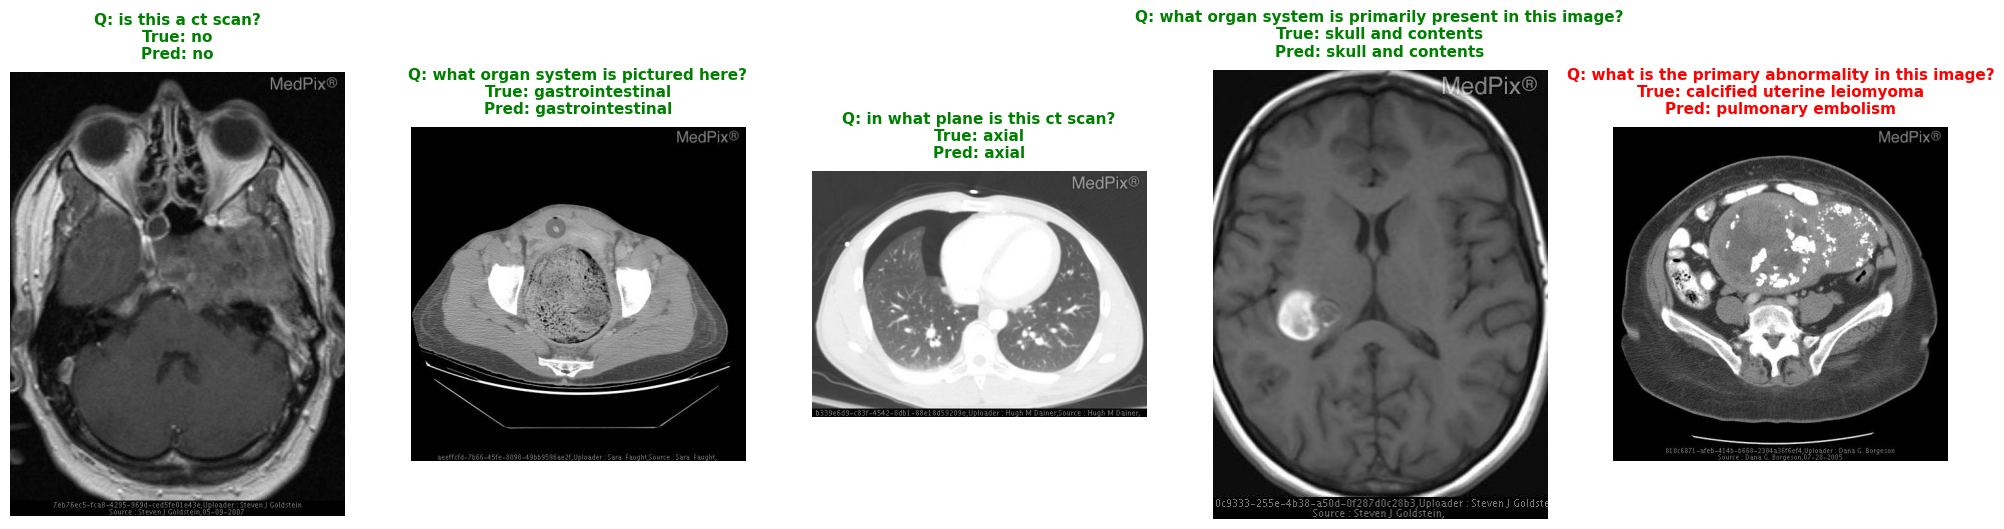

In [59]:
import random
import matplotlib.pyplot as plt
import torch

dataset.reset_format()
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
num_samples = 5
indices = random.sample(range(len(dataset['test'])), num_samples)
fig, axes = plt.subplots(1, num_samples, figsize=(25, 6))

print(f"🔍 Đang chạy dự đoán cho {num_samples} ảnh ngẫu nhiên...\n")

for i, idx in enumerate(indices):
    sample = dataset['test'][idx]
    image = sample['image']
    question = sample['question']
    ground_truth = sample['answer']

    inputs = processor(image, question, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    pred_idx = logits.argmax(-1).item()
    pred_answer = id2label[pred_idx]

    ax = axes[i]
    ax.imshow(image)
    ax.axis('off')

    if pred_answer == ground_truth:
        color = 'green'
        status = "CORRECT"
    else:
        color = 'red'
        status = "WRONG"

    title_text = f"Q: {question}\nTrue: {ground_truth}\nPred: {pred_answer}"

    ax.set_title(title_text, color=color, fontsize=11, fontweight='bold', pad=10)

plt